# Gen AI-Powered Image Captioning: Automating Image Descriptions with AI

## Objective  
To develop an AI-powered system capable of generating accurate and context-aware captions for images using generative models.

## Task List  
- Install necessary libraries.  
- Import essential dependencies.  
- Develop the image captioning model.  
- Create a function for generating captions from images.  
- Design an interactive interface for image captioning.  
- Launch the application.

## Instruction List  
1. Ensure all required libraries are installed before execution.  
2. Import necessary dependencies such as deep learning frameworks and image processing modules.  
3. Load a pre-trained generative model for image captioning.  
4. Implement a function that takes an image as input and generates a relevant caption.  
5. Build an interactive UI to allow users to upload images and receive captions.  

In [1]:
!pip install numpy
!pip install pandas
!pip install gradio
!pip install pillow
!pip install tensorflow
!pip install torch
!pip install torchvision
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Write code for importing necessary libraries

import gradio as  gr
from transformers import BlipProcessor , BlipForConditionalGeneration
from PIL import Image
import torch

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Write code for developing image captioning model

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")


model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
# Write code for developing image captioning function

def generate_caption(image):
    """Generate a caption for the uploaded image"""
    raw_image = Image.open(image).convert("RGB")
    inputs = processor(raw_image,return_tensors='pt')
    with torch.no_grad():
        out =  model.generate(**inputs)  
        caption = processor.decode(out[0],skip_special_tokens=True)
        return caption

In [17]:
# Write code for developing image captioning interface

iface = gr.Interface(
    fn = generate_caption,
    inputs = gr.Image(type = "filepath"),
    outputs = gr.Textbox(label = "Generated Caption"),
    title = "AI Image Captioning",
    description =  "Upload an image, and the AI will generate a descriptive caption for it using the BLIP model."
)

In [18]:
# Write code for launching the app

if __name__ == "__main__":
    iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://f2839ce28715b4930b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Test Image

- Download the given image in your device.
- Use this to generate caption with your model.

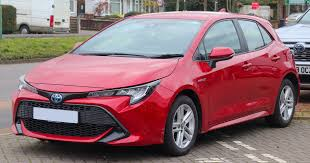

## Conclusion  
This project successfully demonstrates how generative AI can be leveraged to create meaningful captions for images, enhancing automation in image understanding tasks. Future improvements may include integrating multimodal learning for even more accurate captioning.

## Thank You  
Thank you for your interest in this project! Your feedback and suggestions are always welcome to help refine and enhance the capabilities of AI-powered image captioning.